# Pre-training Model Validation


## Checking Backbone Model 

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image

In [12]:
from fairface_vit import FairFaceViT

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

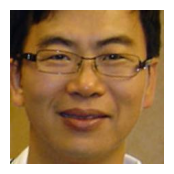

In [13]:
image = Image.open("dataset/temp/image.jpg")

plt.figure(figsize=(2,2))
plt.imshow(image)
plt.axis('off')

### CLIP

In [14]:
from model.clip import model as clip_model, processor as clip_processor

In [ ]:
fairface_clip_model = FairFaceViT(clip_model)

In [16]:
print(clip_model.config)

CLIPVisionConfig {
  "add_cross_attention": false,
  "attention_dropout": 0.0,
  "bos_token_id": null,
  "decoder_start_token_id": null,
  "dropout": 0.0,
  "dtype": "float32",
  "eos_token_id": null,
  "finetuning_task": null,
  "hidden_act": "quick_gelu",
  "hidden_size": 768,
  "image_size": 224,
  "initializer_factor": 1.0,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "layer_norm_eps": 1e-05,
  "model_type": "clip_vision_model",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "pad_token_id": null,
  "patch_size": 16,
  "prefix": null,
  "projection_dim": 512,
  "pruned_heads": {},
  "sep_token_id": null,
  "task_specific_params": null,
  "tie_encoder_decoder": false,
  "tie_word_embeddings": true,
  "tokenizer_class": null,
  "torchscript": false,
  "transformers_version": "5.12.1",
  "use_bfloat16": false
}



In [ ]:
for param in fairface_clip_model.backbone.parameters():
    print(param.requires_grad)

In [ ]:

for name, param in fairface_clip_model.named_parameters():
    if param.requires_grad:
        print(name)


# len(fairface_model.named_parameters())    

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [20]:
total = sum(p.numel() for p in fairface_clip_model.parameters())
trainable = sum(p.numel() for p in fairface_clip_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 86104337
Trainable: 304913
Percentage: 0.3541203737507438


In [21]:
inputs = clip_processor(
    images=image,
    return_tensors='pt'
)

In [ ]:
pixel_values = inputs['pixel_values']
# print(pixel_values)
# print(inputs)


In [23]:
help(fairface_clip_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [24]:
gender_logits, age_logits, race_logits = fairface_clip_model(pixel_values)

In [25]:
print(
    f"gender: {gender_logits.tolist()[0]}\n",
    f"age: {age_logits.tolist()[0]}\n",
    f"race: {race_logits.tolist()[0]}\n"
)

gender: [0.17074428498744965]
 age: [-0.2979312539100647, 0.005929987877607346, -0.08170577883720398, -0.018295440822839737, -0.36485421657562256, 0.06784671545028687, 0.2127518206834793, -0.17980337142944336, 0.31226179003715515]
 race: [0.8462369441986084, 0.4377862215042114, 0.05314724147319794, 0.03838403522968292, -0.5526629090309143, -0.7957065105438232, 0.62018221616745]



In [26]:
gender_prob = torch.sigmoid(gender_logits)
age_prob = torch.softmax(age_logits, dim=1)
race_prob = torch.softmax(race_logits, dim=1)

In [ ]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.5426]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.0838, 0.1136, 0.1041, 0.1109, 0.0784, 0.1209, 0.1397, 0.0943, 0.1543]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.2631, 0.1749, 0.1190, 0.1173, 0.0649, 0.0509, 0.2099]],
       grad_fn=<SoftmaxBackward0>)



### SigLip

In [28]:
from model.siglip import model as siglip_model, processor as siglip_processor

In [ ]:
fairface_siglip_model = FairFaceViT(siglip_model)

In [30]:
print(siglip_model.config)

SiglipVisionConfig {
  "attention_dropout": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu_pytorch_tanh",
  "hidden_size": 768,
  "image_size": 224,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "siglip_vision_model",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "transformers_version": "5.12.1"
}



In [ ]:
for param in fairface_siglip_model.backbone.parameters():
    print(param.requires_grad)

In [32]:
for name, param in fairface_siglip_model.named_parameters():
    if param.requires_grad:
        print(name)

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [33]:
total = sum(p.numel() for p in fairface_siglip_model.parameters())
trainable = sum(p.numel() for p in fairface_siglip_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 93189137
Trainable: 304913
Percentage: 0.327198008068258


In [34]:
inputs = siglip_processor(
    images=image,
    return_tensors='pt'
)

In [ ]:
pixel_values = inputs['pixel_values']
# print(pixel_values)
# print(inputs)

In [36]:
help(fairface_siglip_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [37]:
gender_logits, age_logits, race_logits = fairface_siglip_model(pixel_values)

In [38]:
print(
    f"gender: {gender_logits.tolist()[0]}\n",
    f"age: {age_logits.tolist()[0]}\n",
    f"race: {race_logits.tolist()[0]}\n"
)

gender: [-0.8037462830543518]
 age: [-0.04985971376299858, -0.14147914946079254, -0.012774934992194176, 0.05354347825050354, -0.07496944069862366, 0.12698246538639069, -0.07516477257013321, -0.007074818015098572, -0.049819380044937134]
 race: [-0.10905645787715912, 0.03673489764332771, -0.22317232191562653, 0.062472276389598846, -0.2879371643066406, 0.17116737365722656, 0.24044546484947205]



In [39]:
gender_prob = torch.sigmoid(gender_logits)
age_prob = torch.softmax(age_logits, dim=1)
race_prob = torch.softmax(race_logits, dim=1)

In [40]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.3092]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.1081, 0.0987, 0.1122, 0.1199, 0.1055, 0.1291, 0.1054, 0.1129, 0.1082]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.1280, 0.1481, 0.1142, 0.1519, 0.1070, 0.1694, 0.1815]],
       grad_fn=<SoftmaxBackward0>)



### DinoV2


In [1]:
from model.dinov2 import model as dinov2_model, processor as dinov2_processor

/home/ashkanrn/01-Project/University/Deep-Learning/DL-project/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 223/223 [00:00<00:00, 1281.42it/s]


In [ ]:
fairface_dinov2_model = FairFaceViT(dinov2_model)

In [ ]:
print(dinov2_model.config)

Dinov2Config {
  "apply_layernorm": true,
  "architectures": [
    "Dinov2Model"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 518,
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 14,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12"
  ],
  "transformers_version": "5.12.1",
  "use_mask_token": true,
  "use_swiglu_ffn": false
}



In [ ]:
for param in fairface_dinov2_model.backbone.parameters():
    print(param.requires_grad)

In [ ]:
for name, param in fairface_dinov2_model.named_parameters():
    if param.requires_grad:
        print(name)

gender.weight
gender.bias
age.0.weight
age.0.bias
age.3.weight
age.3.bias
race.weight
race.bias


In [ ]:
total = sum(p.numel() for p in fairface_dinov2_model.parameters())
trainable = sum(p.numel() for p in fairface_dinov2_model.parameters() if p.requires_grad)

print("Total:", total)
print("Trainable:", trainable)
print("Percentage:", trainable / total * 100)

Total: 86885393
Trainable: 304913
Percentage: 0.35093700963060614


In [ ]:
inputs = dinov2_processor(
    images=image,
    return_tensors='pt'
)

In [ ]:
print(dinov2_processor)

BitImageProcessor {
  "crop_size": {
    "height": 224,
    "width": 224
  },
  "do_center_crop": true,
  "do_convert_rgb": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "BitImageProcessor",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 3,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 256
  }
}



In [ ]:
pixel_values_ = inputs['pixel_values']
# print(pixel_values)
# print(inputs)

In [ ]:
help(fairface_dinov2_model.forward)

Help on method forward in module fairface_vit:

forward(x) method of fairface_vit.FairFaceViT instance
    Define the computation performed at every call.

    Should be overridden by all subclasses.

    .. note::
        Although the recipe for forward pass needs to be defined within
        this function, one should call the :class:`Module` instance afterwards
        instead of this since the former takes care of running the
        registered hooks while the latter silently ignores them.



In [ ]:
gender_logits_dinov2, age_logits_dinov2, race_logits_dinov2 = fairface_dinov2_model(pixel_values)

In [ ]:
print(
    f"gender: {gender_logits.tolist()[0]}\n",
    f"age: {age_logits.tolist()[0]}\n",
    f"race: {race_logits.tolist()[0]}\n"
)

gender: [0.08902216702699661]
 age: [0.017394598573446274, -0.038951508700847626, 0.12768083810806274, 0.028938475996255875, -0.0371985100209713, -0.11812351644039154, -0.05966787785291672, -0.027564948424696922, -0.10682888329029083]
 race: [0.2998754680156708, -1.1792526245117188, -0.18584002554416656, -0.37985193729400635, 0.06394936889410019, 0.16221259534358978, -0.08625507354736328]



In [ ]:
gender_prob = torch.sigmoid(gender_logits)
age_prob = torch.softmax(age_logits, dim=1)
race_prob = torch.softmax(race_logits, dim=1)

In [ ]:
print(
    f"gender: {gender_prob}\n",
    f"age: {age_prob}\n",
    f"race: {race_prob}\n"
)

gender: tensor([[0.5222]], grad_fn=<SigmoidBackward0>)
 age: tensor([[0.1155, 0.1092, 0.1290, 0.1168, 0.1094, 0.1009, 0.1069, 0.1104, 0.1020]],
       grad_fn=<SoftmaxBackward0>)
 race: tensor([[0.2132, 0.0486, 0.1312, 0.1080, 0.1684, 0.1858, 0.1449]],
       grad_fn=<SoftmaxBackward0>)



## Validate Image Preprocessing Pipeline

In [3]:
from dataset.transforms import get_train_transform, get_age_transform
from dataset.dataloader import get_dataset, get_dataloaders


/home/ashkanrn/01-Project/University/Deep-Learning/DL-project/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train_set, val_set = get_dataset()
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/datasets/HuggingFaceM4/FairFace/resolve/54d573cdb8b5af490ba8da9da2799628f6e5c496/FairFace.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since HuggingFaceM4/FairFace couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration '0.25' at /home/ashkanrn/.cache/huggingface/datasets/HuggingFaceM4___fair_face/0.25/0.0.0/54d573cdb8b5af490ba8da9da2799628f6e5c496 (last modified on Fri Jul 10 02:49:41 2026).


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6024829..2.0748837].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92156863..0.7176472].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1484597].


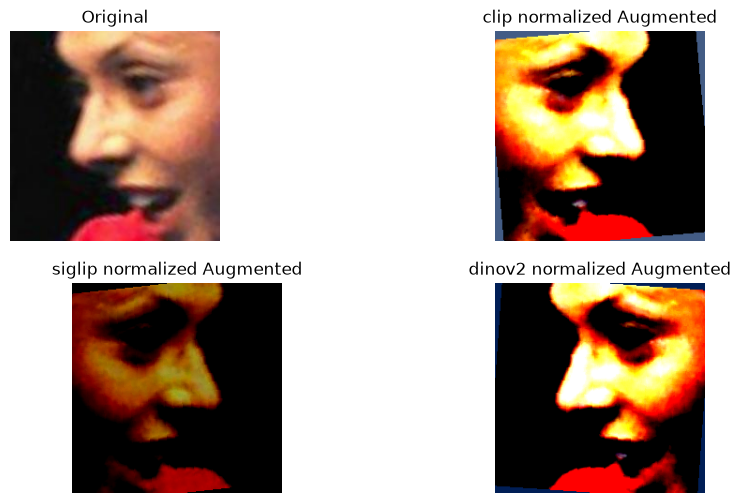

In [7]:
img,label = train_set[5]
# plt.imshow(img)

transform = get_train_transform(clip_processor.image_processor)

age_transform_clip = get_age_transform(clip_processor.image_processor)
age_transform_siglip = get_age_transform(siglip_processor)
age_transform_dinov2 = get_age_transform(dinov2_processor)



plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

transformed_img = age_transform_clip(img)
plt.subplot(2,2,2)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("clip normalized Augmented")
plt.axis("off")

transformed_img = age_transform_siglip(img)
plt.subplot(2,2,3)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("siglip normalized Augmented")
plt.axis("off")

transformed_img = age_transform_dinov2(img)
plt.subplot(2,2,4)
plt.imshow(transformed_img.permute(1, 2, 0))
plt.title("dinov2 normalized Augmented")
plt.axis("off")


plt.show()

## Validate Training Pipeline

In [6]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

In [7]:
from model.clip   import model as clip_model, processor as clip_processor
from model.dinov2 import model as dinov2_model, processor as dinov2_processor
from model.siglip import model as siglip_model, processor as siglip_processor

from fairface_vit import FairFaceViT

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
fairface_clip_model = FairFaceViT(clip_model).to(device)

In [10]:
train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [11]:
print("number of batched: ",len(train_dataloader))
X, Y = next(iter(train_dataloader))
# images and lables blongs to 32 samples (1 batch) 

number of batched:  2711


In [12]:
X, Y = next(iter(train_dataloader))

print("X.shape:" ,X.shape)
print("batch size:" ,X.size(0))

for k, v in Y.items():
    print(k, v.shape, v.dtype)

X.shape: torch.Size([32, 3, 224, 224])
batch size: 32
gender torch.Size([32]) torch.int64
age torch.Size([32]) torch.int64
race torch.Size([32]) torch.int64


In [13]:
X = X.to(device)
Y = {k: v.to(device) for k, v in Y.items()}

pred = fairface_clip_model(X)
# print('pred:', pred)
print(type(pred))
print(len(pred))
    
for k, v in pred.items():
    print(k, v.shape)

<class 'dict'>
3
gender torch.Size([32, 1])
age torch.Size([32, 9])
race torch.Size([32, 7])


### Check Loss fucntions

In [14]:
from training.losses import get_age_weights, get_loss_function, compute_losses

In [15]:
age_labels = np.array(train_set.dataset['age'])
age_weights = get_age_weights(age_labels, 9, device)

In [16]:
loss_funcs = get_loss_function(age_weights)

In [17]:
print(loss_funcs)

{'gender': BCEWithLogitsLoss(), 'age': CrossEntropyLoss(), 'race': CrossEntropyLoss()}


In [18]:
total_loss, losses = compute_losses(pred, Y, loss_funcs)



In [19]:
print(type(total_loss), type(losses))

print(total_loss)

for key,value in losses.items():
    print(key,value)

<class 'torch.Tensor'> <class 'dict'>
tensor(5.0764, device='cuda:0', grad_fn=<AddBackward0>)
gender tensor(0.8177, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
age tensor(2.2292, device='cuda:0', grad_fn=<NllLossBackward0>)
race tensor(2.0296, device='cuda:0', grad_fn=<NllLossBackward0>)


### Check Backward

In [20]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fairface_clip_model.parameters()),
    lr=1e-4,
    weight_decay=0.01
)

# print(optimizer)

In [21]:
optimizer.zero_grad()

total_loss.backward()

optimizer.step()

In [22]:
for name, param in fairface_clip_model.named_parameters():
    if param.requires_grad:
        print(type(param))
        print(name, param.grad.abs().mean())
        break

# fairface_clip_model.named_parameters()    

<class 'torch.nn.parameter.Parameter'>
gender.weight tensor(0.1389, device='cuda:0')


### Check Train loop

In [23]:
from training.train import train_loop

In [24]:
# train_loop(train_dataloader,fairface_clip_model,loss_funcs,None,optimizer,device)

In [25]:
from training.train import test_loop

In [26]:
# test_loop(train_dataloader,fairface_clip_model, loss_funcs, None,device)

## Overfitting Test on a Small Dataset Subset

In [ ]:
from model.clip import model as clip_model, processor as clip_processor

In [2]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [3]:
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from training.train import test_loop

indices = list(range(30))      # first 30 samples
tiny_dataset = Subset(train_set, indices)

In [4]:
tiny_loader = DataLoader(
    tiny_dataset,
    batch_size=8,
    shuffle=True,
)

In [5]:
import numpy as np
from training.train import train_loop,test_loop



In [6]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
from fairface_vit import FairFaceViT
fairface_clip_model = FairFaceViT(clip_model)
fairface_clip_model.to(device)

In [8]:
from training.losses import get_age_weights, get_loss_function, compute_losses
age_labels = np.array(train_set.dataset['age'])
age_weights = get_age_weights(age_labels, 9, device)
loss_funcs = get_loss_function(age_weights)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, fairface_clip_model.parameters()),
    lr=3e-4,
    weight_decay=0.01
)

In [9]:
print(optimizer.param_groups[0]["lr"])

0.0003


In [ ]:
# print(fairface_clip_model.gender.state_dict())

In [11]:
epochs = 50
avg_loss = 0.0
avg_task_losses = {}
overall = {}
subgroups_accuracy = {}
for t in range(epochs):
    print(f"Epoch {t+1}\n--------------------------------------------")
    train_loop(tiny_loader,fairface_clip_model,loss_funcs, None, optimizer, device,t+1,epochs)
    avg_loss, avg_task_losses, overall, subgroups_accuracy = test_loop(tiny_loader, fairface_clip_model, loss_funcs, None, device, t+1, epochs)
    print("\n")
print("Done!")



Epoch 1
--------------------------------------------


 avg loss:        4.8810
 avg age loss:    2.24
 avg gender loss: 0.68
 avg race loss:   1.95

 gender: acc=0.633  f1=0.744
 age:    acc=0.167  f1=0.082  mae=1.433
 race:   acc=0.133  f1=0.114


 avg loss: 4.2707
 gender: acc=0.567  f1=0.698
 age:    acc=0.500  f1=0.272   mae=1.033
 race:   acc=0.300  f1=0.200


Epoch 2
--------------------------------------------


 avg loss:        4.1261
 avg age loss:    1.77
 avg gender loss: 0.62
 avg race loss:   1.73

 gender: acc=0.767  f1=0.837
 age:    acc=0.433  f1=0.294  mae=1.167
 race:   acc=0.233  f1=0.120


 avg loss: 3.7478
 gender: acc=0.700  f1=0.800
 age:    acc=0.400  f1=0.306   mae=1.600
 race:   acc=0.367  f1=0.206


Epoch 3
--------------------------------------------


...

 avg loss: 0.2663
 gender: acc=1.000  f1=1.000
 age:    acc=1.000  f1=1.000   mae=0.000
 race:   acc=1.000  f1=1.000


Epoch 49
--------------------------------------------


 avg loss:        0.2613
 avg age loss:    0.01
 avg gender loss: 0.11
 avg race loss:   0.14

 gender: acc=1.000  f1=1.000
 age:    acc=1.000  f1=1.000  mae=0.000
 race:   acc=1.000  f1=1.000


 avg loss: 0.2716
 gender: acc=1.000  f1=1.000
 age:    acc=1.000  f1=1.000   mae=0.000
 race:   acc=1.000  f1=1.000


Epoch 50
--------------------------------------------


 avg loss:        0.2733
 avg age loss:    0.01
 avg gender loss: 0.12
 avg race loss:   0.14

 gender: acc=1.000  f1=1.000
 age:    acc=1.000  f1=1.000  mae=0.000
 race:   acc=1.000  f1=1.000


 avg loss: 0.2660
 gender: acc=1.000  f1=1.000
 age:    acc=1.000  f1=1.000   mae=0.000
 race:   acc=1.000  f1=1.000


Done!


In [12]:
for key,value in overall.items():
    print(key,value)

gender {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
age {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0, 'mse': 0.0, 'rmse': 0.0, 'mae': 0.0}
race {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
